# Going from 50 to 100 features made a 100-point regression 200× worse

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## A singular value of 0.0038 and a test error of 127

In [1]:
import numpy as np

d, sigma, lam = 20, 0.5, 0.1

def trial(n, p, seed):
    rng = np.random.default_rng(seed)
    theta = rng.standard_normal(d) / np.sqrt(d)           # linear teacher
    X, Xt = rng.standard_normal((n, d)), rng.standard_normal((2000, d))
    y = X @ theta + sigma * rng.standard_normal(n)
    W = rng.standard_normal((d, p))                        # fixed random layer
    feats = lambda A: np.maximum(A @ W, 0) / np.sqrt(p)    # random ReLU features
    U, s, Vt = np.linalg.svd(feats(X), full_matrices=False)
    out = []
    for shrink in (1 / s, s / (s**2 + lam)):               # pinv, then ridge
        w = Vt.T @ (shrink * (U.T @ y))
        out += [np.mean((feats(Xt) @ w - Xt @ theta) ** 2), np.linalg.norm(w)]
    return out + [s.min()]

def sweep(n, p, seeds=range(20)):
    return np.median([trial(n, p, s) for s in seeds], axis=0)

n = 100
print(" p/n   test MSE    ‖w‖    s_min  | ridge MSE   ‖w‖")
for p in (10, 40, 50, 90, 100, 110, 200, 400):
    mse, wn, mse_r, wn_r, smin = sweep(n, p)
    print(f"{p/n:4.1f} {mse:10.3f} {wn:7.2f} {smin:8.4f} | {mse_r:9.3f} {wn_r:5.2f}")

 p/n   test MSE    ‖w‖    s_min  | ridge MSE   ‖w‖
 0.1      0.812    0.79   3.9378 |     0.812  0.79
 0.4      0.462    3.09   0.7568 |     0.422  2.89
 0.5      0.619    3.84   0.5672 |     0.542  3.54


 0.9      3.110   14.17   0.0780 |     0.615  5.66
 1.0    127.249   94.99   0.0038 |     0.612  5.81


 1.1      2.953   14.66   0.0605 |     0.533  5.77


 2.0      0.573    6.85   0.2941 |     0.367  5.09


 4.0      0.311    5.54   0.4386 |     0.248  4.71


## More data can hurt

In [2]:
p = 100
print("   n   test MSE  ridge MSE")
for n in (25, 50, 80, 100, 125, 200, 400):
    mse, _, mse_r, _, _ = sweep(n, p)
    print(f"{n:4d} {mse:10.3f} {mse_r:10.3f}")

   n   test MSE  ridge MSE
  25      0.495      0.473
  50      0.621      0.500
  80      1.897      0.636


 100    127.249      0.612
 125      1.270      0.547


 200      0.386      0.318
 400      0.154      0.148


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

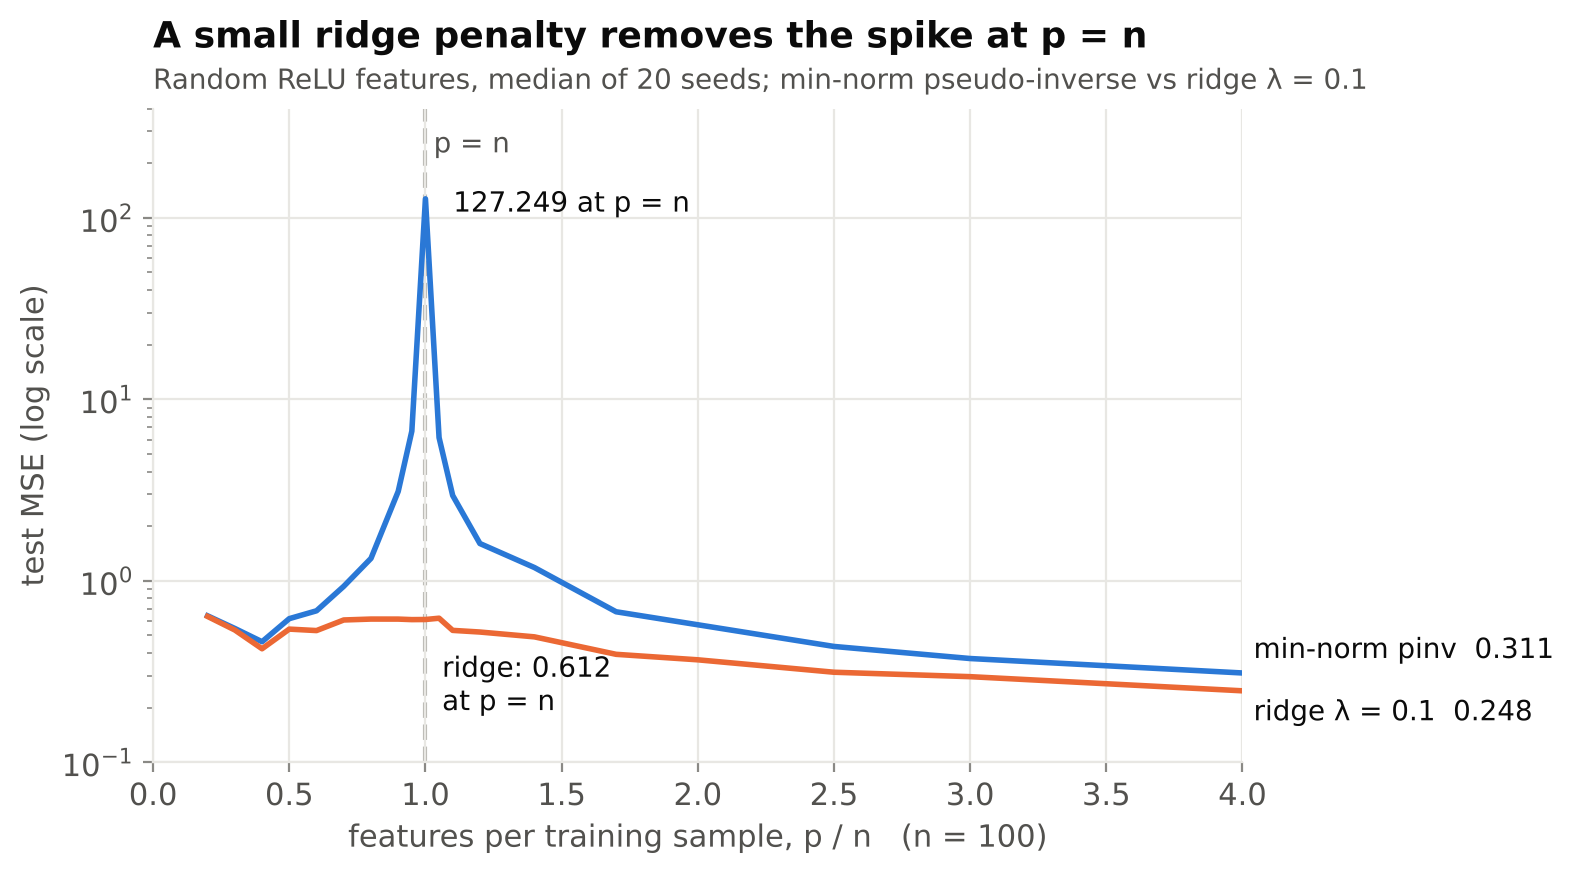

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # trial() and sweep() exactly as in the article; each trial is seeded by its
    # seed alone, so the article's p values reproduce its printed table.
    d, sigma, lam = 20, 0.5, 0.1


    def trial(n, p, seed):
        rng = np.random.default_rng(seed)
        theta = rng.standard_normal(d) / np.sqrt(d)
        X, Xt = rng.standard_normal((n, d)), rng.standard_normal((2000, d))
        y = X @ theta + sigma * rng.standard_normal(n)
        W = rng.standard_normal((d, p))
        feats = lambda A: np.maximum(A @ W, 0) / np.sqrt(p)
        U, s, Vt = np.linalg.svd(feats(X), full_matrices=False)
        out = []
        for shrink in (1 / s, s / (s**2 + lam)):
            w = Vt.T @ (shrink * (U.T @ y))
            out += [np.mean((feats(Xt) @ w - Xt @ theta) ** 2), np.linalg.norm(w)]
        return out + [s.min()]


    def sweep(n, p, seeds=range(20)):
        return np.median([trial(n, p, s) for s in seeds], axis=0)


    n = 100
    ps = [20, 30, 40, 50, 60, 70, 80, 90, 95, 100, 105, 110, 120, 140, 170, 200, 250, 300, 400]
    res = {p: sweep(n, p) for p in ps}
    for p in (50, 90, 100, 110, 200, 400):
        print(f"p/n={p/n:.1f}  pinv {res[p][0]:.3f}  ridge {res[p][2]:.3f}")

    r = np.array(ps) / n
    mse = np.array([res[p][0] for p in ps])
    mse_r = np.array([res[p][2] for p in ps])

    f, ax = fig()
    ax.axvline(1.0, color=NEUTRAL, lw=1.5, ls="--", zorder=1)
    ax.text(1.03, 300, "p = n", color=INK_2, fontsize=10, va="top")
    ax.plot(r, mse, color=S1, zorder=3)
    ax.plot(r, mse_r, color=S2, zorder=3)
    ax.annotate(f"{res[100][0]:.3f} at p = n", (1.0, res[100][0]), xytext=(10, -2),
                textcoords="offset points", color=INK, fontsize=10, va="center")
    ax.annotate(f"ridge: {res[100][2]:.3f}\nat p = n", (1.0, res[100][2]), xytext=(6, -12),
                textcoords="offset points", color=INK, fontsize=10, va="top", ha="left")
    label_end(ax, r[-1], mse[-1], f"min-norm pinv  {mse[-1]:.3f}", S1, dy=8)
    label_end(ax, r[-1], mse_r[-1], f"ridge λ = 0.1  {mse_r[-1]:.3f}", S2, dy=-8)

    ax.set_yscale("log")
    ax.set_xlim(0, 4)
    ax.set_ylim(0.1, 400)
    ax.set_xlabel("features per training sample, p / n   (n = 100)")
    ax.set_ylabel("test MSE (log scale)")
    ax.set_title("A small ridge penalty removes the spike at p = n")
    subtitle(ax, "Random ReLU features, median of 20 seeds; min-norm pseudo-inverse vs ridge λ = 0.1")
    save(f, pathlib.Path(__file__).parent / "15-double-descent.png")
import matplotlib.pyplot as plt
plt.show()